# Digit-Reader

MNIST CNN for handwritten digits 0–9. Everything is in this notebook — run cells top to bottom.

Kernel: **Digit-Reader (3.13)** → `.venv\\Scripts\\python.exe`

In [13]:
from pathlib import Path

import numpy as np
from keras.callbacks import EarlyStopping
from keras.datasets import mnist
from keras.layers import Conv2D, Dense, Dropout, Flatten, Input, MaxPooling2D
from keras.models import Sequential, load_model
from keras.optimizers import Adam
from keras.utils import to_categorical
from PIL import Image, ImageFilter

try:
    import matplotlib.pyplot as plt

    HAS_MATPLOTLIB = True
except ImportError:
    from IPython.display import display

    HAS_MATPLOTLIB = False

ROOT = Path.cwd()
MODEL_PATH = ROOT / "saved_models" / "mnist.keras"
IMAGE_PATH = ROOT / "Untitled.png"

In [14]:
def load_mnist_arrays():
    (x_train, y_train), (x_test, y_test) = mnist.load_data()
    x_train = x_train.reshape(x_train.shape[0], 28, 28, 1).astype("float32") / 255.0
    x_test = x_test.reshape(x_test.shape[0], 28, 28, 1).astype("float32") / 255.0
    y_train = to_categorical(y_train, 10)
    y_test = to_categorical(y_test, 10)
    return (x_train, y_train), (x_test, y_test)


def build_model(num_classes=10):
    model = Sequential(
        [
            Input(shape=(28, 28, 1)),
            Conv2D(32, kernel_size=(3, 3), activation="relu"),
            Conv2D(64, (3, 3), activation="relu"),
            MaxPooling2D(pool_size=(2, 2)),
            Dropout(0.25),
            Flatten(),
            Dense(256, activation="relu"),
            Dropout(0.5),
            Dense(num_classes, activation="softmax"),
        ]
    )
    model.compile(
        loss="categorical_crossentropy",
        optimizer=Adam(),
        metrics=["accuracy"],
    )
    return model


def _to_ink_on_black(arr):
    if arr.mean() > 127:
        arr = 255.0 - arr
    return arr


def _ink_bbox(arr, threshold=20.0):
    rows = np.any(arr > threshold, axis=1)
    cols = np.any(arr > threshold, axis=0)
    if not rows.any() or not cols.any():
        return None
    rmin, rmax = np.where(rows)[0][[0, -1]]
    cmin, cmax = np.where(cols)[0][[0, -1]]
    return rmin, rmax, cmin, cmax


def _thicken_thin_strokes(arr):
    ink_ratio = float((arr > 20).mean())
    if ink_ratio >= 0.05:
        return np.where(arr > 20, arr, 0.0).astype(np.float32)
    passes = 3 if ink_ratio < 0.02 else 2
    binary = (arr > 20).astype(np.uint8) * 255
    img = Image.fromarray(binary, mode="L")
    for _ in range(passes):
        img = img.filter(ImageFilter.MaxFilter(3))
    return np.asarray(img, dtype=np.float32)


def _fit_to_20(arr):
    h, w = arr.shape
    scale = 20.0 / max(h, w)
    new_h = max(1, int(round(h * scale)))
    new_w = max(1, int(round(w * scale)))
    resized = np.asarray(
        Image.fromarray(arr).resize((new_w, new_h), Image.Resampling.BILINEAR),
        dtype=np.float32,
    )
    canvas = np.zeros((20, 20), dtype=np.float32)
    y0 = (20 - new_h) // 2
    x0 = (20 - new_w) // 2
    canvas[y0 : y0 + new_h, x0 : x0 + new_w] = resized
    return canvas


def _center_of_mass(arr):
    total = float(arr.sum())
    if total <= 0:
        return 13.5, 13.5
    ys, xs = np.indices(arr.shape)
    return float((ys * arr).sum() / total), float((xs * arr).sum() / total)


def _shift(arr, dy, dx):
    out = np.zeros_like(arr)
    h, w = arr.shape
    src_y0 = max(0, -dy)
    src_y1 = min(h, h - dy)
    src_x0 = max(0, -dx)
    src_x1 = min(w, w - dx)
    dst_y0 = max(0, dy)
    dst_y1 = dst_y0 + (src_y1 - src_y0)
    dst_x0 = max(0, dx)
    dst_x1 = dst_x0 + (src_x1 - src_x0)
    if src_y1 > src_y0 and src_x1 > src_x0:
        out[dst_y0:dst_y1, dst_x0:dst_x1] = arr[src_y0:src_y1, src_x0:src_x1]
    return out


def _normalize_peak(arr):
    peak = float(arr.max())
    if peak <= 0:
        return arr
    return np.clip(arr / peak, 0.0, 1.0).astype(np.float32)


def preprocess_image(image_path):
    arr = np.asarray(Image.open(Path(image_path)).convert("L"), dtype=np.float32)
    arr = _to_ink_on_black(arr)
    if arr.shape == (28, 28) and float((arr > 20).mean()) >= 0.05:
        return _normalize_peak(arr).reshape(1, 28, 28, 1)
    arr = _thicken_thin_strokes(arr)
    bbox = _ink_bbox(arr)
    if bbox is None:
        return np.zeros((1, 28, 28, 1), dtype=np.float32)
    rmin, rmax, cmin, cmax = bbox
    pad = 2
    rmin = max(0, rmin - pad)
    cmin = max(0, cmin - pad)
    rmax = min(arr.shape[0] - 1, rmax + pad)
    cmax = min(arr.shape[1] - 1, cmax + pad)
    cropped = arr[rmin : rmax + 1, cmin : cmax + 1]
    digit20 = _fit_to_20(cropped)
    canvas = np.zeros((28, 28), dtype=np.float32)
    canvas[4:24, 4:24] = digit20
    cy, cx = _center_of_mass(canvas)
    canvas = _shift(canvas, int(round(14 - cy)), int(round(14 - cx)))
    return _normalize_peak(canvas).reshape(1, 28, 28, 1)


def show_array(arr, scale=8):
    pixels = np.clip(arr.squeeze(), 0.0, 1.0)
    if HAS_MATPLOTLIB:
        plt.imshow(pixels, cmap="gray")
        plt.axis("off")
        plt.show()
        return
    from IPython.display import display

    img = Image.fromarray((pixels * 255).astype(np.uint8), mode="L")
    display(img.resize((pixels.shape[1] * scale, pixels.shape[0] * scale), Image.Resampling.NEAREST))

In [15]:
(x_train, y_train), (x_test, y_test) = load_mnist_arrays()
x_train.shape, y_train.shape, x_test.shape, y_test.shape

((60000, 28, 28, 1), (60000, 10), (10000, 28, 28, 1), (10000, 10))

In [16]:
if MODEL_PATH.exists():
    model = load_model(MODEL_PATH)
    test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)
else:
    model = build_model()
    history = model.fit(
        x_train,
        y_train,
        batch_size=128,
        epochs=12,
        validation_split=0.1,
        callbacks=[
            EarlyStopping(
                monitor="val_accuracy",
                patience=3,
                restore_best_weights=True,
            )
        ],
        verbose=1,
    )
    MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
    model.save(MODEL_PATH)
    test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)
test_loss, test_accuracy

(0.03173322230577469, 0.9908999800682068)

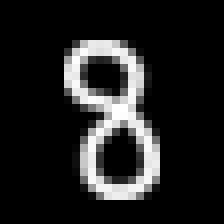

(8, 100.0)

In [17]:
model = load_model(MODEL_PATH)
img = preprocess_image(IMAGE_PATH)
show_array(img)

probs = model.predict(img, verbose=0)[0]
digit = int(np.argmax(probs))
confidence = float(probs[digit] * 100.0)
digit, confidence